In [182]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy.stats as st
from uncertainties import ufloat
import uncertainties
from uncertainties.umath import *
pd.set_option('future.no_silent_downcasting', True)
from statannotations.Annotator import Annotator


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [183]:
figure_folder = Path('../../Figures/interactions')
figure_folder.mkdir(exist_ok=True)

In [184]:
folder = Path('../../data/5_interactions/')
df = pd.read_csv(folder / 'all_interactions_cfus.csv')

In [185]:
tab10 = sns.color_palette('tab10')
species_palette = {
    'At': tab10[2],
    'Ct': tab10[1],
    'Oa': tab10[3],
    'Ml': tab10[0]
    
}

# Quantify interactions

In [186]:
df.reset_index(drop=True)
df['Is coculture'] = ['+' in x for x in df['Inoculated species']]
 

In [187]:
df.Medium.unique()

array(['Ml_mannose', 'Ct_isoleucine', 'Oa_mannose', 'No CS', 'At_mannose',
       'M9_mannose', 'M9_mannose+thiamine',
       'M9_mannose+thiamine+biotin+cysteine+proline', 'M9_isoleucine',
       'M9_isoleucine+thiamine+biotin+cysteine+proline',
       'M9_isoleucine+thiamine', 'At_malate', 'Ct_malate', 'Ml_malate',
       'Oa_malate', 'M9_malate', 'M9_malate+thiamine',
       'M9_malate+thiamine+biotin+cysteine+proline'], dtype=object)

In [188]:
df['log10(CFUs/mL)'] = np.log10(df['CFUs/mL'])


In [189]:

four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in df.Medium.unique():
    if medium == 'No CS':
        continue
    dfm = df.loc[df.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    print(coculture_pairs)
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'log10(CFUs/mL)'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'log10(CFUs/mL)'].dropna()
        # s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        # s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        s1_mono_log = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co_log = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())

        lrr_s1 = s1_co_log - s1_mono_log
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co, equal_var=False, alternative='two-sided')
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'log10(CFUs/mL)'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'log10(CFUs/mL)'].dropna()

        
        
        s2_mono_log = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co_log = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        
        lrr_s2 = s2_co_log - s2_mono_log
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co, equal_var=False, alternative='two-sided')

        if np.isnan(max(ttest_res1.pvalue, ttest_res2.pvalue)):
            print(pair)  
            print(s1_growth_in_mono.values, s1_growth_in_co.values)      
            print(s2_growth_in_mono.values, s2_growth_in_co.values)      
        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
interactions_df = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])


['At+Ct' 'At+Oa' 'Ct+Oa']
['At+Ml' 'At+Oa' 'Ml+Oa']
['At+Ml' 'Ct+Ml' 'At+Ct']
['Ct+Ml' 'Ct+Oa' 'Ml+Oa']
['At+Ct' 'At+Ml' 'At+Oa' 'Ct+Ml' 'Ct+Oa' 'Ml+Oa']
['At+Oa' 'Ct+Oa' 'Ml+Oa']
['At+Ml' 'Ct+Ml' 'Ml+Oa']
[]
[]
[]
['Ct+Ml' 'Ct+Oa' 'Ml+Oa']
['At+Ml' 'At+Oa' 'Ml+Oa']
['At+Ct' 'At+Oa' 'Ct+Oa']
['At+Ct' 'At+Ml' 'Ct+Ml']
At+Ct
[9.74818803] [8.04139269 8.02530587 8.01703334]
[7.60205999 7.76342799 7.74818803] [8.02530587 8.03342376 8.02530587]
At+Ml
[9.74818803] [8.69897    8.60205999 8.71600334]
[7.25527251 7.47712125 7.25527251] [7.44715803 7.5563025  7.60205999]
['At+Ct' 'At+Ml' 'At+Oa' 'Ct+Ml' 'Ct+Oa' 'Ml+Oa']
['At+Oa' 'Ct+Oa' 'Ml+Oa']
['At+Ml' 'Ct+Ml' 'Ml+Oa']


In [190]:
from statsmodels.stats.multitest import multipletests

# Perform multiple test correction using the Benjamini-Hochberg procedure
pvalues = interactions_df['T-test pvalue']

# Create a mask for non-NaN values
valid_mask = ~pvalues.isna()

# Initialize corrected p-values with NaN
corrected_pvalues = pd.Series([np.nan] * len(pvalues), index=pvalues.index)

# Apply correction only to valid (non-NaN) p-values
if valid_mask.sum() > 0:
    valid_pvals = pvalues[valid_mask]
    corrected_valid = multipletests(valid_pvals, method='fdr_bh')[1]
    corrected_pvalues[valid_mask] = corrected_valid

# Add the corrected p-values to the DataFrame
interactions_df['Corrected pvalue'] = corrected_pvalues

In [191]:
interactions_df['log10 pval'] = np.log10(interactions_df['T-test pvalue'])
interactions_df['log10 adj. pval'] = np.log10(interactions_df['Corrected pvalue'])

In [192]:
interactions_df['Significance annot'] = ''
for i, row in interactions_df.iterrows():
    pval = row['Corrected pvalue']
    if pd.isna(pval):
        annot = ''
    elif 0.01 < pval < 0.05:
        annot = '*'
    elif 0.001 < pval < 0.01:
        annot = '**'
    elif pval < 0.001:
        annot = '***'
    else:
        annot = ''
    interactions_df.at[i, 'Significance annot'] = annot
    

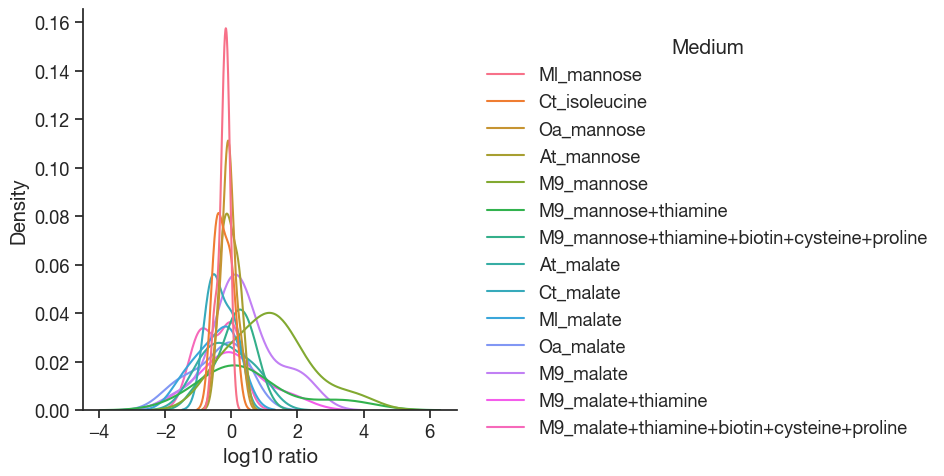

In [193]:
ax = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Medium', kind = 'kde')


In [194]:
interactions_df['Fresh'] = ['Fresh' if x.split('_')[0]=='M9' else 'Spent' for x in interactions_df.Medium]

In [195]:
interactions_df.to_csv(folder / 'all_interactions_cfus_with_stats.csv', index=False)

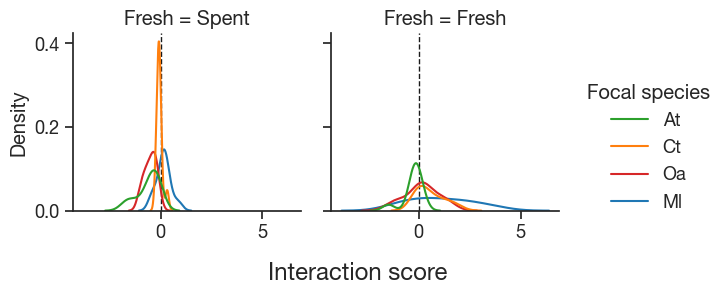

In [196]:
g = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Focal species', palette=species_palette, fill = False, 
                kind = 'kde', col='Fresh', aspect=1, height=3)#, alpha = 0.5)
for ax in g.axes.flat:
     ax.axvline(0, ls = '--', c = 'k', zorder=0, lw=1)
     ax.set_xlabel('')
g.fig.supxlabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_species.pdf')



In [197]:
interactions_df.loc[(interactions_df['Focal species']=='Ml')&(interactions_df['Fresh']=='Fresh')].sort_values('log10 ratio')

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval,Significance annot,Fresh
93,Ml,Ct,M9_malate+thiamine+biotin+cysteine+proline,-1.084987,0.271797,2.656215e-04,0.002497,-3.575737,-2.602609,**,Fresh
91,Ml,At,M9_malate+thiamine+biotin+cysteine+proline,-0.892159,0.250549,4.007582e-04,0.003425,-3.397118,-2.465382,**,Fresh
94,Ml,Oa,M9_malate+thiamine+biotin+cysteine+proline,-0.769969,0.176876,1.541857e-03,0.007819,-2.811956,-2.106842,**,Fresh
43,Ml,At,M9_mannose+thiamine+biotin+cysteine+proline,0.132269,0.177800,1.897554e-01,0.278707,-0.721806,-0.554852,,Fresh
45,Ml,Ct,M9_mannose+thiamine+biotin+cysteine+proline,0.180498,0.162035,7.739487e-02,0.145502,-1.111288,-0.837130,,Fresh
82,Ml,Oa,M9_malate,0.486636,0.373585,6.338985e-02,0.129536,-1.197980,-0.887610,,Fresh
46,Ml,Oa,M9_mannose+thiamine+biotin+cysteine+proline,0.535023,0.239949,5.491567e-03,0.021509,-2.260304,-1.667387,*,Fresh
31,Ml,Ct,M9_mannose,1.005781,0.499604,2.724424e-02,0.067394,-1.564725,-1.171381,,Fresh
88,Ml,Oa,M9_malate+thiamine,1.672514,0.432220,4.086645e-03,0.017908,-2.388633,-1.746959,*,Fresh
79,Ml,Ct,M9_malate,1.962409,0.260525,4.191172e-03,0.017908,-2.377665,-1.746959,*,Fresh


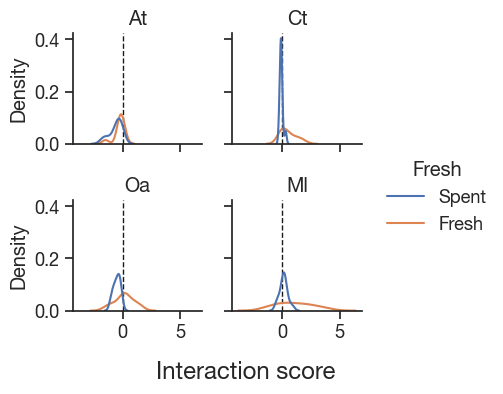

In [198]:
g = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Fresh', fill = False, 
                kind = 'kde', col='Focal species', aspect=1, height=2, col_wrap=2)#, alpha = 0.5)
for ax in g.axes.flat:
     ax.axvline(0, ls = '--', c = 'k', zorder=0, lw=1)
     ax.set_xlabel('')
g.fig.supxlabel('Interaction score')
g.set_titles("{col_name}")
plt.savefig(figure_folder / f'interaction_distribution_species_fresh_spent.pdf')

In [199]:
interactions_df.groupby(['Focal species', 'Fresh']).agg({'log10 ratio': ['mean', 'std']}).reset_index().rename(columns = {'mean': 'Mean', 'std': 'Std'})

Focal species  Fresh log10 ratio          
                              Mean       Std
0            At  Fresh   -0.262180  0.457788
1            At  Spent   -0.602430  0.546125
2            Ct  Fresh    0.553404  0.667434
3            Ct  Spent   -0.052843  0.139834
4            Ml  Fresh    1.059175  1.526538
5            Ml  Spent    0.148180  0.346590
6            Oa  Fresh    0.139187  0.816444
7            Oa  Spent   -0.507339  0.293057

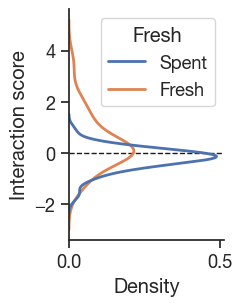

In [200]:
fig, ax = plt.subplots(figsize = (2, 3))
ax = sns.kdeplot(data = interactions_df, y = 'log10 ratio', hue = 'Fresh', lw=2)
ax.axhline(0, ls = '--', c = 'k', zorder=0, lw = 1)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_fresh_spent.pdf')

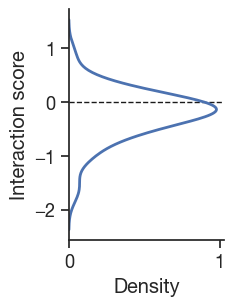

In [201]:
fig, ax = plt.subplots(figsize = (2, 3))
ax = sns.kdeplot(data = interactions_df.loc[interactions_df.Fresh=='Spent'], y = 'log10 ratio',lw=2)
ax.axhline(0, ls = '--', c = 'k', zorder=0, lw = 1)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_fresh_spent.pdf')

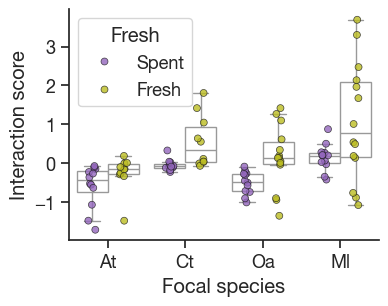

In [202]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Focal species', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Focal species', hue = 'Fresh',dodge=True, palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_boxplots_focal_species.pdf', bbox_inches='tight')


In [203]:
interactions_df.groupby(['Focal species', 'Fresh'])['log10 ratio'].describe()

count      mean       std       min       25%       50%  \
Focal species Fresh                                                            
At            Fresh   10.0 -0.262180  0.457788 -1.487251 -0.283832 -0.159893   
              Spent   12.0 -0.602430  0.546125 -1.720277 -0.749051 -0.449445   
Ct            Fresh   10.0  0.553404  0.667434 -0.073533  0.030112  0.327633   
              Spent   12.0 -0.052843  0.139834 -0.231803 -0.117047 -0.079716   
Ml            Fresh   14.0  1.059175  1.526538 -1.084987  0.144326  0.770402   
              Spent   12.0  0.148180  0.346590 -0.427742  0.010502  0.193385   
Oa            Fresh   14.0  0.139187  0.816444 -1.360330 -0.033012  0.130514   
              Spent   12.0 -0.507339  0.293057 -1.016528 -0.727363 -0.482512   

                          75%       max  
Focal species Fresh                      
At            Fresh -0.033016  0.182812  
              Spent -0.212105 -0.078356  
Ct            Fresh  0.940368  1.805656  
              Spent -0.029223  0.323453  
Ml            Fresh  2.091105  3.692150  
              Spent  0.266197  0.872558  
Oa            Fresh  0.542262  1.414905  
              Spent -0.277195 -0.092470

In [204]:

# Test for each combination of Fresh and Focal species
results = []
for fresh in interactions_df['Fresh'].unique():
    for species in interactions_df['Focal species'].unique():
        data = interactions_df.loc[(interactions_df['Fresh'] == fresh) & 
                                   (interactions_df['Focal species'] == species), 'log10 ratio'].dropna()
        
        if len(data) > 0:
            t_stat, p_value = st.ttest_1samp(data, popmean=0)
            results.append({
                'Fresh': fresh,
                'Focal species': species,
                'N': len(data),
                'Mean': data.mean(),
                'Std': data.std(),
                't-statistic': t_stat,
                'p-value': p_value
            })

results_df = pd.DataFrame(results)
print(results_df)

   Fresh Focal species   N      Mean       Std  t-statistic   p-value
0  Spent            At  12 -0.602430  0.546125    -3.821245  0.002837
1  Spent            Ct  12 -0.052843  0.139834    -1.309082  0.217193
2  Spent            Oa  12 -0.507339  0.293057    -5.997031  0.000090
3  Spent            Ml  12  0.148180  0.346590     1.481027  0.166666
4  Fresh            At  10 -0.262180  0.457788    -1.811069  0.103559
5  Fresh            Ct  10  0.553404  0.667434     2.622009  0.027719
6  Fresh            Oa  14  0.139187  0.816444     0.637877  0.534628
7  Fresh            Ml  14  1.059175  1.526538     2.596117  0.022169


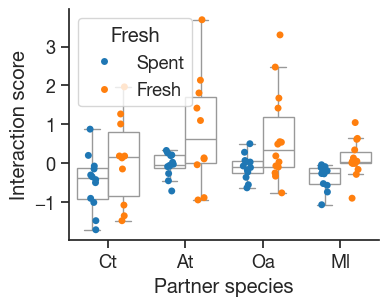

In [205]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Partner species', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Partner species', hue = 'Fresh',dodge=True, palette='tab10')# palette=species_palette)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_boxplots_partner_species.pdf', bbox_inches='tight')




In [206]:

groups = [group['log10 ratio'].values for name, group in interactions_df.groupby('Fresh')]

# Perform one-way ANOVA
f_stat, p_value = st.kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 14.130637886597924
P-value: 0.00017054334475321


Spent: t-statistic = -3.732437016050978, p-value = 0.0005111037796443849, mean -0.254, std = 0.471
Fresh: t-statistic = 2.5918686314035813, p-value = 0.012679121732457483, mean 0.410, std = 1.096
MWU 639.0 0.0001730577639481078
Welchs -3.8541311212975105 0.0002724937111712869

Levene's Test (variance equality):
  W-statistic = 11.3045, p-value = 0.0011
  → Variances are significantly different (p < 0.05)


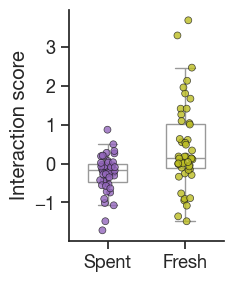

In [207]:
fig, ax = plt.subplots(1, figsize=(2,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False, width=0.5)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', hue = 'Fresh', palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

# pairs = [['Spent', 'Fresh']]

# annotator = Annotator(
#     ax, pairs, data=interactions_df, y = 'log10 ratio', x = 'Fresh' #orient="h" 
# )
# # plt.ylim(0,2)
# annotator.configure(text_format="star", loc="inside",
#     hide_non_significant=True, alpha=0.05)
# annotator.set_pvalues_and_annotate([p_value])

# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Perform Mann-Whitney 
u_stat, p_value_mw = st.mannwhitneyu(spent_data, fresh_data)

w_stat, p_value_w = st.ttest_ind(spent_data, fresh_data, equal_var = False, alternative = 'two-sided')

# Perform Levene's test to check if variances differ between Fresh and Spent
levene_stat, levene_p = st.levene(spent_data, fresh_data)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")

print(f'MWU', u_stat, p_value_mw)
print('Welchs', w_stat, p_value_w)



print(f"\nLevene's Test (variance equality):")
print(f"  W-statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
if levene_p < 0.05:
    print(f"  → Variances are significantly different (p < 0.05)")
else:
    print(f"  → Variances are not significantly different (p ≥ 0.05)")
    
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.png', bbox_inches='tight', dpi=300)

In [208]:
# spent_cfu_values = df.loc[(df.spent == True)&(df['Base carbon source']!='No CS'), 'log10(CFUs/mL)'].values
spent_cfu_values = df.loc[(df.spent == True)&(df['Base carbon source']!='No CS')].groupby(['Species', 'Inoculated species', 'Medium'])['log10(CFUs/mL)'].mean().reset_index()['log10(CFUs/mL)'].values
# fresh_cfu_values = df.loc[(df.spent == False)&(df['Base carbon source']!='No CS'), 'log10(CFUs/mL)'].values
fresh_cfu_values = df.loc[(df.spent == False)&(df['Base carbon source']!='No CS')].groupby(['Species', 'Inoculated species', 'Medium'])['log10(CFUs/mL)'].mean().reset_index()['log10(CFUs/mL)'].values

In [209]:
def calc_interactions(vals, iterations = 10000):
    pairs = [tuple(np.random.choice(vals, size=2, replace=False)) for _ in range(iterations)]
    interactions = [b-a for a,b in pairs]
    return interactions

Spent: t-statistic = -3.732437016050978, p-value = 0.0005111037796443849, mean -0.254, std = 0.471
Spent: t-statistic wilcoxon = 231.0, p-value = 0.00014651492903539065, mean -0.254, std = 0.471
Fresh: t-statistic = 2.5918686314035813, p-value = 0.012679121732457483, mean 0.410, std = 1.096
Fresh: t-statistic wilcoxon = 364.0, p-value = 0.020921503209237358, mean 0.410, std = 1.096
MWU 639.0 0.0001730577639481078
Welchs -3.8541311212975105 0.0002724937111712869


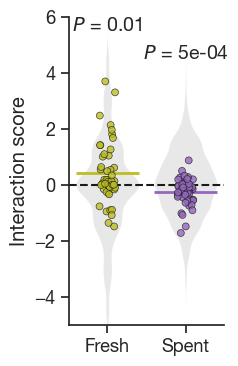

In [210]:
fig, ax = plt.subplots(1, figsize=(2,4))
# ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', color = 'w', fliersize=0, 
#                  hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False, width=0.5)
fresh_order = ['Fresh', 'Spent']

sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', hue = 'Fresh', palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8, order = fresh_order) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

fresh_random = calc_interactions(fresh_cfu_values)
spent_random = calc_interactions(spent_cfu_values)

# Create dataframe from random pairs
random_df = pd.DataFrame({
    'log10 ratio': fresh_random + spent_random,
    'Fresh': ['Fresh']*len(fresh_random) + ['Spent']*len(spent_random)
})


# Create violin plot
sns.violinplot(data=random_df, y='log10 ratio', x='Fresh', order=fresh_order, hue = 'Fresh', hue_order = fresh_order,
               palette=['lightgray', 'lightgray'], ax=ax, inner = None, alpha = 0.5, linewidth = 0)
sns.despine()

ax.axhline(0, ls = '--', c = 'k')

# Add mean lines for each group
spent_mean = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio'].mean()
fresh_mean = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio'].mean()

# Draw horizontal lines at the mean for each category
ax.hlines(spent_mean, xmin=0.6, xmax=1.4, colors=tab10[4], linewidth=2, linestyle='-', label=f'Spent mean: {spent_mean:.3f}')
ax.hlines(fresh_mean, xmin=-0.4, xmax=0.4, colors=tab10[8], linewidth=2, linestyle='-', label=f'Fresh mean: {fresh_mean:.3f}')


# # Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)
t_stat_spent_w, p_value_spent_w = st.wilcoxon(spent_data)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)
t_stat_fresh_w, p_value_fresh_w = st.wilcoxon(fresh_data)

# Perform Mann-Whitney 
u_stat, p_value_mw = st.mannwhitneyu(spent_data, fresh_data)

w_stat, p_value_w = st.ttest_ind(spent_data, fresh_data, equal_var = False, alternative = 'two-sided')

# annotator = Annotator(
#     ax, [fresh_order], data=interactions_df, y = 'log10 ratio', x = 'Fresh' #orient="h" 
# )
# annotator.configure(text_format="full", loc="inside",
#     hide_non_significant=True)
# annotator.set_pvalues_and_annotate([p_value_mw])
ax.text(x = 0, y = 5.5, s = r'$P$'+ f' = {p_value_fresh:.2f}', ha = 'center', size = 14)
ax.text(x = 1, y = 4.5, s = r'$P$'+ f' = {p_value_spent:.0e}', ha = 'center', size = 14)

print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Spent: t-statistic wilcoxon = {t_stat_spent_w}, p-value = {p_value_spent_w}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")
print(f"Fresh: t-statistic wilcoxon = {t_stat_fresh_w}, p-value = {p_value_fresh_w}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")
print(f'MWU', u_stat, p_value_mw)
print('Welchs', w_stat, p_value_w)
plt.ylim(-5,6)    
plt.xlabel('')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent_random_permutations.pdf', bbox_inches='tight')
# plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.png', bbox_inches='tight', dpi=300)

Spent: Wilcoxon statistic = 105.0, p-value = 5.394826985138934e-08, median 0.377
Fresh: Wilcoxon statistic = 374.0, p-value = 0.027618201382949792, median 0.781
Random medians: Spent = 0.799, Fresh = 0.964


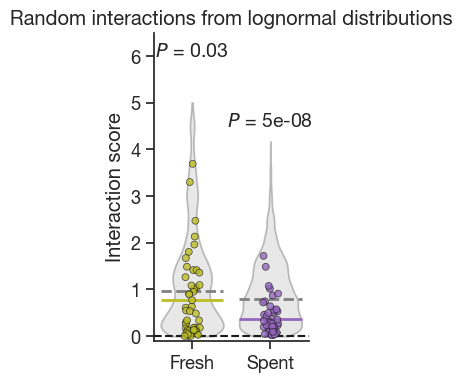

In [211]:
# Generate random interactions from lognormal distributions
fig, ax = plt.subplots(1, figsize=(2,4))
interactions_df['abs(log10 ratio)'] = interactions_df['log10 ratio'].abs()
sns.stripplot(data = interactions_df, y = 'abs(log10 ratio)', x = 'Fresh', 
            order=fresh_order, hue = 'Fresh', hue_order = fresh_order,
             palette=[tab10[8], tab10[4]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

random_df['abs(log10 ratio)'] = random_df['log10 ratio'].abs()
# Create violin plot
sns.violinplot(data=random_df, y='abs(log10 ratio)', x='Fresh', order=fresh_order, 
               hue='Fresh', hue_order=fresh_order,
               palette=['lightgray', 'lightgray'], ax=ax, inner=None, alpha=0.5, cut = 0)
sns.despine()

ax.axhline(0, ls='--', c='k')

# Add mean lines for each group
spent_median = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'abs(log10 ratio)'].mean()
spent_values = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'abs(log10 ratio)'].values
fresh_median = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'abs(log10 ratio)'].mean()
fresh_values = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'abs(log10 ratio)'].values

spent_random_median = random_df.loc[random_df['Fresh']=='Spent', 'abs(log10 ratio)'].median()
fresh_random_median = random_df.loc[random_df['Fresh']=='Fresh', 'abs(log10 ratio)'].median()


t_stat_spent, p_value_spent = st.wilcoxon(spent_values - spent_random_median)
t_stat_fresh, p_value_fresh = st.wilcoxon(fresh_values - fresh_random_median)
print(f"Spent: Wilcoxon statistic = {t_stat_spent}, p-value = {p_value_spent}, median {spent_median:.3f}")
print(f"Fresh: Wilcoxon statistic = {t_stat_fresh}, p-value = {p_value_fresh}, median {fresh_median:.3f}")
print(f'Random medians: Spent = {spent_random_median:.3f}, Fresh = {fresh_random_median:.3f}')
# Draw horizontal lines at the mean for each category
ax.hlines(spent_median, xmin=0.6, xmax=1.4, colors=tab10[4], linewidth=2, linestyle='-')
ax.hlines(spent_random_median, xmin=0.6, xmax=1.4, colors='gray', linewidth=2, linestyle='--')

ax.hlines(fresh_median, xmin=-0.4, xmax=0.4, colors=tab10[8], linewidth=2, linestyle='-')
ax.hlines(fresh_random_median, xmin=-.4, xmax=.4, colors='gray', linewidth=2, linestyle='--')

ax.text(x = 0, y = 6, s = r'$P$'+ f' = {p_value_fresh:.2f}', ha = 'center', size = 14)
ax.text(x = 1, y = 4.5, s = r'$P$'+ f' = {p_value_spent:.0e}', ha = 'center', size = 14)

plt.ylim(-0.1,6.5)
plt.xlabel('')
# plt.ylabel
plt.title('Random interactions from lognormal distributions')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent_permuations_abs.pdf', bbox_inches='tight')


Spent: p5=6.939, p95=9.410, μ=8.174, σ=0.751
Fresh: p5=6.662, p95=10.116, μ=8.389, σ=1.050
Spent: t-statistic = -3.732437016050978, p-value = 0.0005111037796443849, mean -0.254, std = 0.471
Fresh: t-statistic = 2.5918686314035813, p-value = 0.012679121732457483, mean 0.410, std = 1.096


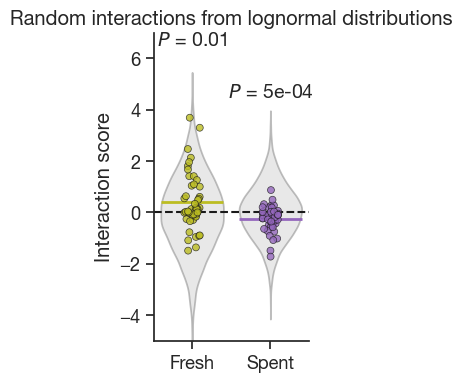

In [212]:
# Generate random interactions from lognormal distributions
fig, ax = plt.subplots(1, figsize=(2,4))
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh',
            order=fresh_order, hue = 'Fresh', hue_order = fresh_order,
              palette=[tab10[8], tab10[4]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

# Get 5th and 95th percentiles from actual CFU data
spent_p5 = np.percentile(spent_cfu_values, 5)
spent_p95 = np.percentile(spent_cfu_values, 95)
fresh_p5 = np.percentile(fresh_cfu_values, 5)
fresh_p95 = np.percentile(fresh_cfu_values, 95)

# Calculate lognormal parameters to match these percentiles
# For lognormal: p5 = exp(μ + σ*z_0.05), p95 = exp(μ + σ*z_0.95)
# where z_0.05 ≈ -1.645, z_0.95 ≈ 1.645
z_0_05 = st.norm.ppf(0.05)
z_0_95 = st.norm.ppf(0.95)

# Solve for μ and σ (data is already in log10 scale)
spent_log_std = (spent_p95 - spent_p5) / (z_0_95 - z_0_05)
spent_log_mean = (spent_p5 + spent_p95) / 2

fresh_log_std = (fresh_p95 - fresh_p5) / (z_0_95 - z_0_05)
fresh_log_mean = (fresh_p5 + fresh_p95) / 2

print(f"Spent: p5={spent_p5:.3f}, p95={spent_p95:.3f}, μ={spent_log_mean:.3f}, σ={spent_log_std:.3f}")
print(f"Fresh: p5={fresh_p5:.3f}, p95={fresh_p95:.3f}, μ={fresh_log_mean:.3f}, σ={fresh_log_std:.3f}")


# # Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)
# t_stat_spent_w, p_value_spent_w = st.wilcoxon(spent_data)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)
# t_stat_fresh_w, p_value_fresh_w = st.wilcoxon(fresh_data)
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")

# Generate random samples from lognormal distributions
n_samples = 10000
spent_lognormal = np.random.normal(spent_log_mean, spent_log_std, (n_samples, 2))
fresh_lognormal = np.random.normal(fresh_log_mean, fresh_log_std, (n_samples, 2))
# Calculate interactions from lognormal samples
def calc_interactions_from_array(vals, iterations=10000):
    interactions = [a-b for a,b in vals]
    return interactions

fresh_random_lognorm = calc_interactions_from_array(fresh_lognormal)
spent_random_lognorm = calc_interactions_from_array(spent_lognormal)

# Create dataframe from random pairs
random_lognorm_df = pd.DataFrame({
    'log10 ratio': fresh_random_lognorm + spent_random_lognorm,
    'Fresh': ['Fresh']*len(fresh_random_lognorm) + ['Spent']*len(spent_random_lognorm)
})

# Create violin plot
sns.violinplot(data=random_lognorm_df, y='log10 ratio', x='Fresh', order=fresh_order, 
               hue='Fresh', hue_order=fresh_order,
               palette=['lightgray', 'lightgray'], ax=ax, inner=None, alpha=0.5, cut = 0)
sns.despine()

ax.axhline(0, ls='--', c='k')

# Add mean lines for each group
spent_mean = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio'].mean()
fresh_mean = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio'].mean()

# Draw horizontal lines at the mean for each category
ax.hlines(spent_mean, xmin=0.6, xmax=1.4, colors=tab10[4], linewidth=2, linestyle='-')
ax.hlines(fresh_mean, xmin=-0.4, xmax=0.4, colors=tab10[8], linewidth=2, linestyle='-')

ax.text(x = 0, y = 6.5, s = r'$P$'+ f' = {p_value_fresh:.2f}', ha = 'center', size = 14)
ax.text(x = 1, y = 4.5, s = r'$P$'+ f' = {p_value_spent:.0e}', ha = 'center', size = 14)
plt.xlabel('')
plt.ylim(-5, 7)    
plt.title('Random interactions from lognormal distributions')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent_lognormal.pdf', bbox_inches='tight')


In [213]:
random_lognorm_df.groupby('Fresh')['log10 ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
Fresh,,,,,,,,
Fresh,10000.0,-0.010754,1.488730,-5.319133,-1.013648,-0.000494,0.995529,5.457093
Spent,10000.0,0.002604,1.050304,-4.151514,-0.699814,0.007217,0.686777,3.961915


Spent: Wilcoxon statistic = 145.0, p-value = 1.0875185623149264e-06, median 0.377, fraction of random:0.543
Fresh: Wilcoxon statistic = 341.0, p-value = 0.010558738569429238, median 0.781, fraction of random:0.777
Random medians: Spent = 0.694, Fresh = 1.005


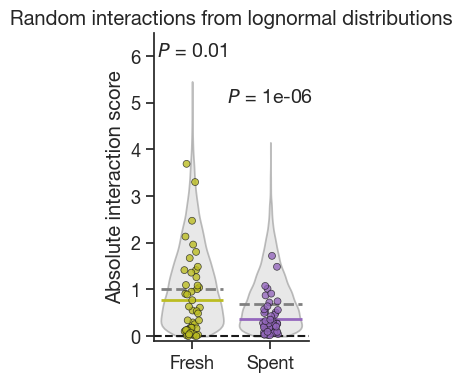

In [214]:
# Generate random interactions from lognormal distributions
fig, ax = plt.subplots(1, figsize=(2,4))
interactions_df['abs(log10 ratio)'] = interactions_df['log10 ratio'].abs()
sns.stripplot(data = interactions_df, y = 'abs(log10 ratio)', x = 'Fresh', 
            order=fresh_order, hue = 'Fresh', hue_order = fresh_order,
             palette=[tab10[8], tab10[4]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

random_lognorm_df['abs(log10 ratio)'] = random_lognorm_df['log10 ratio'].abs()
# Create violin plot
sns.violinplot(data=random_lognorm_df, y='abs(log10 ratio)', x='Fresh', order=fresh_order, 
               hue='Fresh', hue_order=fresh_order,
               palette=['lightgray', 'lightgray'], ax=ax, inner=None, alpha=0.5, cut = 0)
sns.despine()

ax.axhline(0, ls='--', c='k')

# Add mean lines for each group
spent_median = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'abs(log10 ratio)'].mean()
spent_values = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'abs(log10 ratio)'].values
fresh_median = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'abs(log10 ratio)'].mean()
fresh_values = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'abs(log10 ratio)'].values

spent_random_median = random_lognorm_df.loc[random_lognorm_df['Fresh']=='Spent', 'abs(log10 ratio)'].median()
fresh_random_median = random_lognorm_df.loc[random_lognorm_df['Fresh']=='Fresh', 'abs(log10 ratio)'].median()


t_stat_spent, p_value_spent = st.wilcoxon(spent_values - spent_random_median)
t_stat_fresh, p_value_fresh = st.wilcoxon(fresh_values - fresh_random_median)
print(f"Spent: Wilcoxon statistic = {t_stat_spent}, p-value = {p_value_spent}, median {spent_median:.3f}, fraction of random:{spent_median/spent_random_median:.3f}")
print(f"Fresh: Wilcoxon statistic = {t_stat_fresh}, p-value = {p_value_fresh}, median {fresh_median:.3f}, fraction of random:{fresh_median/fresh_random_median:.3f}")
print(f'Random medians: Spent = {spent_random_median:.3f}, Fresh = {fresh_random_median:.3f}')

# Draw horizontal lines at the mean for each category
ax.hlines(spent_median, xmin=0.6, xmax=1.4, colors=tab10[4], linewidth=2, linestyle='-')
ax.hlines(spent_random_median, xmin=0.6, xmax=1.4, colors='gray', linewidth=2, linestyle='--')

ax.hlines(fresh_median, xmin=-0.4, xmax=0.4, colors=tab10[8], linewidth=2, linestyle='-')
ax.hlines(fresh_random_median, xmin=-.4, xmax=.4, colors='gray', linewidth=2, linestyle='--')


ax.text(x = 0, y = 6, s = r'$P$'+ f' = {p_value_fresh:.2f}', ha = 'center', size = 14)
ax.text(x = 1, y = 5, s = r'$P$'+ f' = {p_value_spent:.0e}', ha = 'center', size = 14)
plt.xlabel('')
plt.ylim(-0.1,6.5)    
plt.title('Random interactions from lognormal distributions')
plt.ylabel('Absolute interaction score')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent_lognormal_abs.pdf', bbox_inches='tight')


0.009743714693309253 1.1761342849616176
-0.003160544150742211 1.6439910169397962
Spent: t-statistic = -3.875838598327152, p-value = 0.0003285079484940141, mean -0.224, std = 0.400
Fresh: t-statistic = 2.6118389702845057, p-value = 0.012051776525823727, mean 0.251, std = 0.667
MWU 596.0 4.691267577185967e-05
Welchs -4.233907824552302 6.29330204958921e-05

Levene's Test (variance equality):
  W-statistic = 4.7903, p-value = 0.0311
  → Variances are significantly different (p < 0.05)


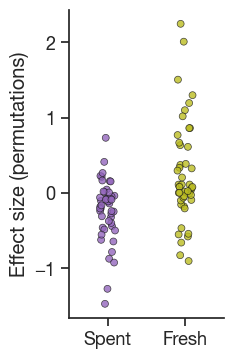

In [215]:
# Calculate std from random permutations
spent_random_std = np.std(spent_random)
fresh_random_std = np.std(fresh_random)

spent_random_mean = np.mean(spent_random)
fresh_random_mean = np.mean(fresh_random)

print(spent_random_mean, spent_random_std)
print(fresh_random_mean, fresh_random_std)

interactions_df['Effect size (permutations)'] = np.nan
for i, row in interactions_df.iterrows():
    if row['Fresh'] == 'Spent':
        interactions_df.at[i, 'Effect size (permutations)'] = (row['log10 ratio'] - spent_random_mean) / spent_random_std
    else:
        interactions_df.at[i, 'Effect size (permutations)'] = (row['log10 ratio'] - fresh_random_mean) / fresh_random_std

# Generate random interactions from lognormal distributions
fig, ax = plt.subplots(1, figsize=(2,4))
sns.stripplot(data = interactions_df, y = 'Effect size (permutations)', x = 'Fresh', hue = 'Fresh', 
              palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8)
sns.despine()
ax.set_ylabel('Effect size (permutations)')
plt.xlabel('')

# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'Effect size (permutations)']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'Effect size (permutations)']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Perform Mann-Whitney 
u_stat, p_value_mw = st.mannwhitneyu(spent_data, fresh_data)

w_stat, p_value_w = st.ttest_ind(spent_data, fresh_data, equal_var = False, alternative = 'two-sided')

# Perform Levene's test to check if variances differ between Fresh and Spent
levene_stat, levene_p = st.levene(spent_data, fresh_data)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")

print(f'MWU', u_stat, p_value_mw)
print('Welchs', w_stat, p_value_w)



print(f"\nLevene's Test (variance equality):")
print(f"  W-statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
if levene_p < 0.05:
    print(f"  → Variances are significantly different (p < 0.05)")
else:
    print(f"  → Variances are not significantly different (p ≥ 0.05)")
    

0.002603965779950915 1.0502511310747946
-0.010753905916381118 1.4886555915130493
Spent: t-statistic = -3.7707604712004175, p-value = 0.0004544764284057311, mean -0.244, std = 0.448
Fresh: t-statistic = 2.6598186853185917, p-value = 0.010658914422490258, mean 0.283, std = 0.737
MWU 596.0 4.691267577185967e-05
Welchs -4.2324114149258 6.281169532055687e-05

Levene's Test (variance equality):
  W-statistic = 4.5525, p-value = 0.0355
  → Variances are significantly different (p < 0.05)


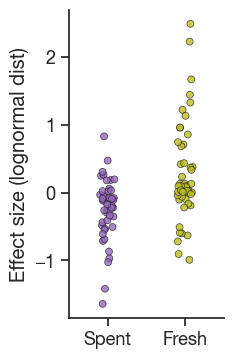

In [216]:
# Calculate std from random permutations
spent_random_std = np.std(spent_random_lognorm)
fresh_random_std = np.std(fresh_random_lognorm)

spent_random_mean = np.mean(spent_random_lognorm)
fresh_random_mean = np.mean(fresh_random_lognorm)

print(spent_random_mean, spent_random_std)
print(fresh_random_mean, fresh_random_std)

interactions_df['Effect size (lognormal dist)'] = np.nan
for i, row in interactions_df.iterrows():
    if row['Fresh'] == 'Spent':
        interactions_df.at[i, 'Effect size (lognormal dist)'] = (row['log10 ratio'] - spent_random_mean) / spent_random_std
    else:
        interactions_df.at[i, 'Effect size (lognormal dist)'] = (row['log10 ratio'] - fresh_random_mean) / fresh_random_std

# Generate random interactions from lognormal distributions
fig, ax = plt.subplots(1, figsize=(2,4))
sns.stripplot(data = interactions_df, y = 'Effect size (lognormal dist)', x = 'Fresh', hue = 'Fresh', 
              palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8)
sns.despine()
ax.set_ylabel('Effect size (lognormal dist)')
plt.xlabel('')

# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'Effect size (lognormal dist)']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'Effect size (lognormal dist)']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Perform Mann-Whitney 
u_stat, p_value_mw = st.mannwhitneyu(spent_data, fresh_data)

w_stat, p_value_w = st.ttest_ind(spent_data, fresh_data, equal_var = False, alternative = 'two-sided')

# Perform Levene's test to check if variances differ between Fresh and Spent
levene_stat, levene_p = st.levene(spent_data, fresh_data)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")

print(f'MWU', u_stat, p_value_mw)
print('Welchs', w_stat, p_value_w)



print(f"\nLevene's Test (variance equality):")
print(f"  W-statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
if levene_p < 0.05:
    print(f"  → Variances are significantly different (p < 0.05)")
else:
    print(f"  → Variances are not significantly different (p ≥ 0.05)")
    

Spent: t-statistic = 112.0, p-value = 9.545255608145453e-08, mean 0.325, std = 0.322
Fresh: t-statistic = 6.248464248589294, p-value = 1.1311218316137337e-07, mean 0.476, std = 0.527
MWU 1069.0 0.5454916914629685
Welchs -1.691172884280615 0.09480947847579507

Levene's Test (variance equality):
  W-statistic = 6.3393, p-value = 0.0135
  → Variances are significantly different (p < 0.05)
0.22126280614980554
0.3126476858283677
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Spent vs. Fresh: Custom statistical test, P_val:5.455e-01


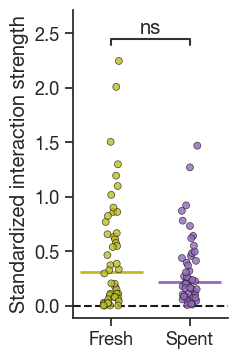

In [217]:
interactions_df['abs effect (permutations)'] = np.abs(interactions_df['Effect size (permutations)'])
# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'abs effect (permutations)']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'abs effect (permutations)']

# Test if the mean of 'Spent' is different from 0
#  = st.ttest_1samp(spent_data, 0)

t_stat_spent, p_value_spent = st.wilcoxon(spent_data - 0.674)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Perform Mann-Whitney 
u_stat, p_value_mw = st.mannwhitneyu(spent_data, fresh_data)

w_stat, p_value_w = st.ttest_ind(spent_data, fresh_data, equal_var = False, alternative = 'two-sided')

# Perform Levene's test to check if variances differ between Fresh and Spent
levene_stat, levene_p = st.levene(spent_data, fresh_data)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")

print(f'MWU', u_stat, p_value_mw)
print('Welchs', w_stat, p_value_w)



print(f"\nLevene's Test (variance equality):")
print(f"  W-statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
if levene_p < 0.05:
    print(f"  → Variances are significantly different (p < 0.05)")
else:
    print(f"  → Variances are not significantly different (p ≥ 0.05)")

fig, ax = plt.subplots(1, figsize=(2,4))
sns.stripplot(data = interactions_df, y = 'abs effect (permutations)', x = 'Fresh', hue = 'Fresh', order = fresh_order, 
              palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8)
sns.despine()
plt.ylabel('Standardized interaction strength')

# Draw horizontal lines at the mean for each category
ax.hlines(spent_data.median(), xmin=.6, xmax=1.4, colors=tab10[4], linewidth=2, linestyle='-')
ax.hlines(fresh_data.median(), xmin=-.4, xmax=0.4, colors=tab10[8], linewidth=2, linestyle='-')
ax.axhline(0, ls='--', c='k')
annotator = Annotator(
    ax, [['Spent', 'Fresh']], data=interactions_df, y = 'abs effect (permutations)', x = 'Fresh' #orient="h" 
)
print(spent_data.median())
print(fresh_data.median())
annotator.configure(text_format="star", loc="inside",
    hide_non_significant=False)
annotator.set_pvalues_and_annotate([p_value_mw])
plt.xlabel('')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent_effect_size.pdf', bbox_inches='tight')

Spent: t-statistic = 6.952854180006804, p-value = 9.636482318129376e-09, mean 0.360, std = 0.359
Fresh: t-statistic = 6.25486216050522, p-value = 1.1061199288238242e-07, mean 0.527, std = 0.584
MWU 1059.0 0.49789486233338276
Welchs -1.6829242432351221 0.09638182949443828

Levene's Test (variance equality):
  W-statistic = 6.2455, p-value = 0.0142
  → Variances are significantly different (p < 0.05)


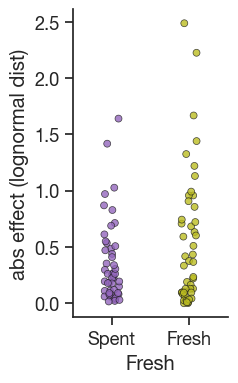

In [218]:
interactions_df['abs effect (lognormal dist)'] = np.abs(interactions_df['Effect size (lognormal dist)'])
# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'abs effect (lognormal dist)']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'abs effect (lognormal dist)']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Perform Mann-Whitney 
u_stat, p_value_mw = st.mannwhitneyu(spent_data, fresh_data)

w_stat, p_value_w = st.ttest_ind(spent_data, fresh_data, equal_var = False, alternative = 'two-sided')

# Perform Levene's test to check if variances differ between Fresh and Spent
levene_stat, levene_p = st.levene(spent_data, fresh_data)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}, std = {spent_data.std():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}, std = {fresh_data.std():.3f}")

print(f'MWU', u_stat, p_value_mw)
print('Welchs', w_stat, p_value_w)



print(f"\nLevene's Test (variance equality):")
print(f"  W-statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
if levene_p < 0.05:
    print(f"  → Variances are significantly different (p < 0.05)")
else:
    print(f"  → Variances are not significantly different (p ≥ 0.05)")

fig, ax = plt.subplots(1, figsize=(2,4))
sns.stripplot(data = interactions_df, y = 'abs effect (lognormal dist)', x = 'Fresh', hue = 'Fresh', 
              palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8)
sns.despine()

In [219]:


# interactions_df[['Focal species', 'Partner species', 'Medium', 'log10 ratio', 'T-test pvalue', 'Corrected pvalue', 'Effect size (permutations)', 'CS', 'Fresh']].to_csv(folder / 'all_interactions_cfus_with_stats.csv', index=False)

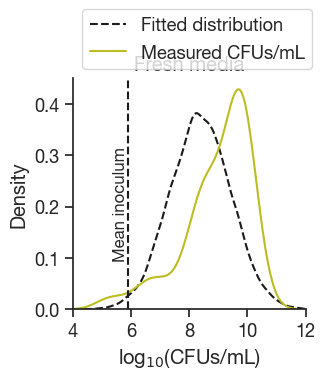

In [220]:
mean_inoc = 5.89
fig, ax = plt.subplots(1, figsize = (3,3))
sns.kdeplot(fresh_lognormal.flatten(), log_scale = False, label = 'Fitted distribution', ax = ax, c = 'k', ls = '--')
sns.kdeplot(fresh_cfu_values, label = 'Measured CFUs/mL', log_scale = False, ax = ax, c = tab10[8])
ax.axvline(mean_inoc, ls = '--', c = 'k')
ax.text(mean_inoc, 0.1, 'Mean inoculum', rotation = 90,size = 12, ha = 'right')
plt.legend()
sns.move_legend(ax, loc = 'lower left', bbox_to_anchor = (0,1))
ax.set_xlim(4, 12)
plt.xlabel(r'log$_{10}$(CFUs/mL)')
ax.set_title('Fresh media')
sns.despine()
plt.savefig(figure_folder / f'fresh_cfu_distribution.pdf', bbox_inches='tight')

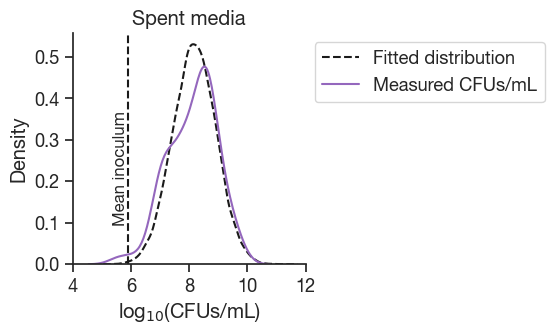

In [221]:
fig, ax = plt.subplots(1, figsize = (3,3))
sns.kdeplot(spent_lognormal.flatten(), log_scale = False, label = 'Fitted distribution', ax = ax, c = 'k', ls = '--')
sns.kdeplot(spent_cfu_values, label = 'Measured CFUs/mL', log_scale = False, ax = ax, c = tab10[4])
ax.axvline(mean_inoc, ls = '--', c = 'k')
ax.text(mean_inoc, 0.1, 'Mean inoculum', rotation = 90,size = 12, ha = 'right')
plt.legend()
sns.move_legend(ax, loc = 'upper left', bbox_to_anchor = (1,1))
ax.set_xlim(4, 12)
ax.set_title('Spent media')
plt.xlabel(r'log$_{10}$(CFUs/mL)')

sns.despine()
plt.savefig(figure_folder / f'spent_cfu_distribution.pdf', bbox_inches='tight')

In [222]:
interactions_df['Significance'] = interactions_df['Corrected pvalue']<0.05
interactions_df.groupby('Fresh').agg({'Significance':'sum'})

,Significance
Fresh,
Fresh,24
Spent,9


In [223]:
interactions_df['abs log10 ratio'] = np.abs(interactions_df['log10 ratio'])
interactions_df[['abs log10 ratio', 'Fresh']].groupby('Fresh').agg(['mean', 'median', 'std'])

abs log10 ratio                    
                 mean    median       std
Fresh                                    
Fresh        0.781192  0.510829  0.866512
Spent        0.377257  0.266632  0.376751

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_81818/621205132.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


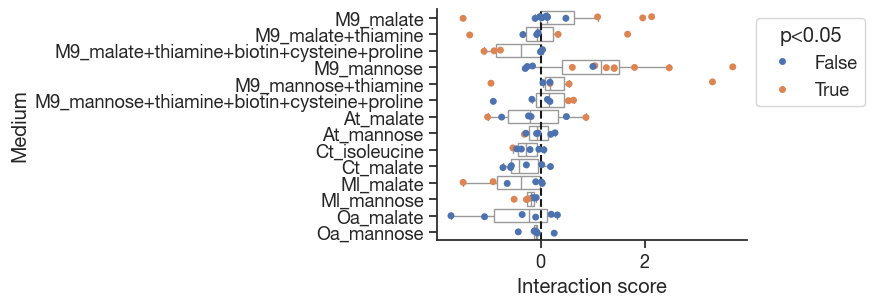

In [224]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = interactions_df.sort_values(by=['Fresh','Medium']), x = 'log10 ratio', y = 'Medium', hue = 'Significance', ax=ax)# palette='copper', 
sns.boxplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', color = 'w', fliersize=0)
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
sns.move_legend(ax, title='p<0.05', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine()
plt.xlabel('Interaction score')
plt.savefig(figure_folder/'Interactions_per_medium.pdf')

In [225]:
for i, row in interactions_df.iterrows():
    cs = row['Medium'].split('+')[0].split('_')[1]
    interactions_df.at[i, 'CS'] = cs.capitalize()

In [226]:
row

Focal species                                                           Oa
Partner species                                                         Ml
Medium                          M9_malate+thiamine+biotin+cysteine+proline
log10 ratio                                                        0.00244
log10 ratio std                                                   0.157582
T-test pvalue                                                      0.97631
Corrected pvalue                                                  0.984088
log10 pval                                                       -0.010412
log10 adj. pval                                                  -0.006966
Significance annot                                                        
Fresh                                                                Fresh
abs(log10 ratio)                                                   0.00244
Effect size (permutations)                                        0.003407
Effect size (lognormal di

Ml_mannose Ct Oa ** -0.5068606190712384
Ml_mannose At Oa * -0.2708470025128147
Ml_mannose Oa At ** -0.2317279530405063


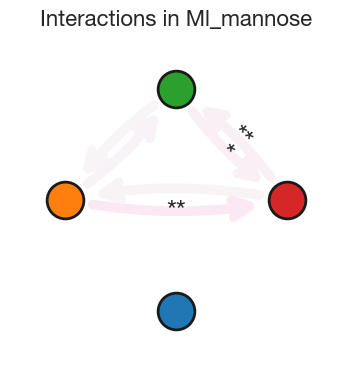

Ct_isoleucine Ml At * -0.5306466761412612


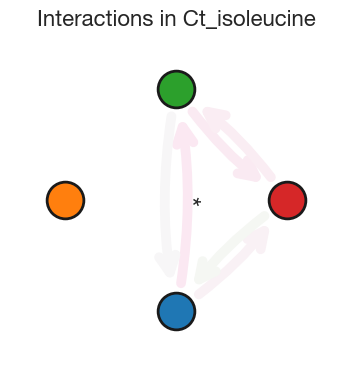

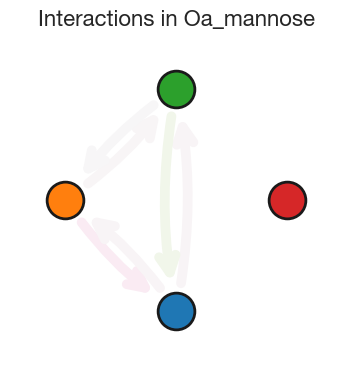

At_mannose Ct Oa * -0.30905051279219364


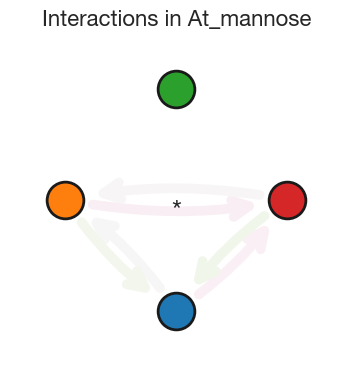

M9_mannose Ml Oa ** 0.6106344584263681
M9_mannose Ml Ct *** 1.0425108690406386
M9_mannose Ct Oa *** 1.26378226398033
M9_mannose At Oa *** 1.4149049000430622
M9_mannose Oa Ct *** 1.415027608271025
M9_mannose At Ct *** 1.8056558959665807
M9_mannose Oa Ml ** 2.4725004032961593
M9_mannose At Ml ** 3.692150276739092


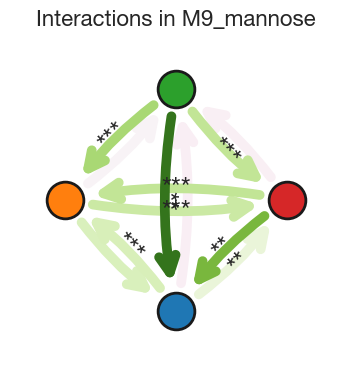

M9_mannose+thiamine At Oa * -0.9521644203597592
M9_mannose+thiamine Oa At * 0.18281182565525178
M9_mannose+thiamine Oa Ct * 0.5488799527235022
M9_mannose+thiamine Oa Ml *** 3.3017813731989127


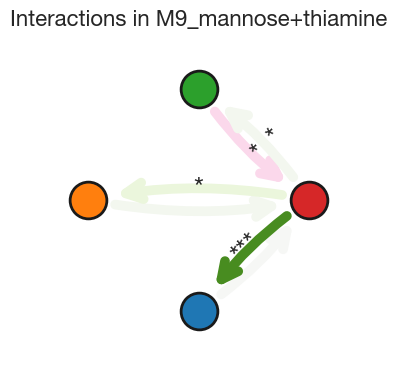

M9_mannose+thiamine+biotin+cysteine+proline Oa Ml * 0.5350225201702301
M9_mannose+thiamine+biotin+cysteine+proline Ml Ct ** 0.633939568364088


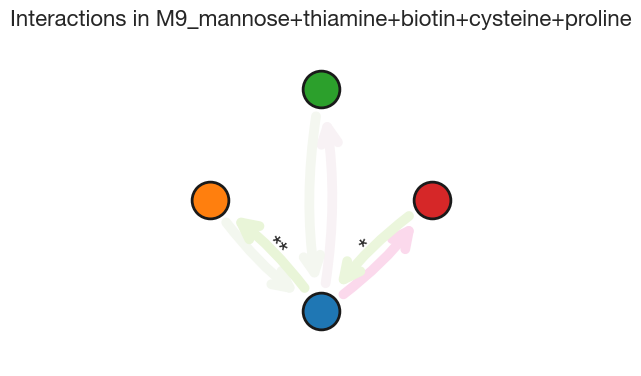

At_malate Ct Oa * -1.0165283582733249
At_malate Ct Ml * 0.8725584948369169


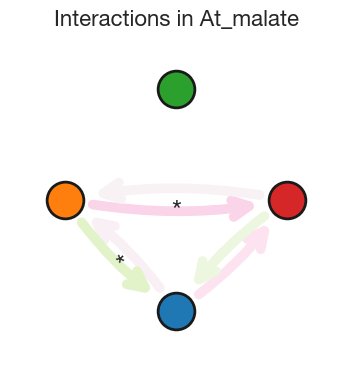

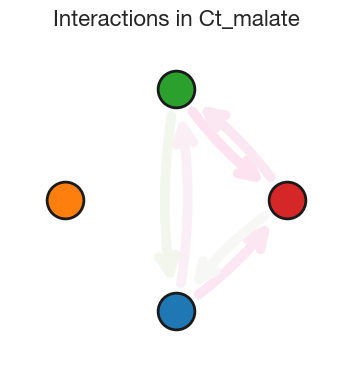

Ml_malate Ct At * -1.4862056459382753
Ml_malate Ct Oa * -0.9106682393182606


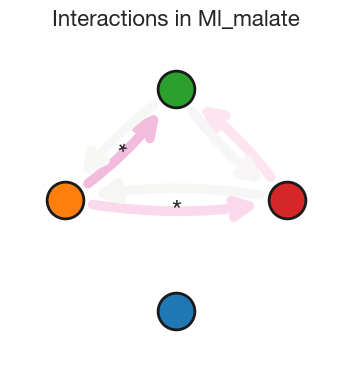

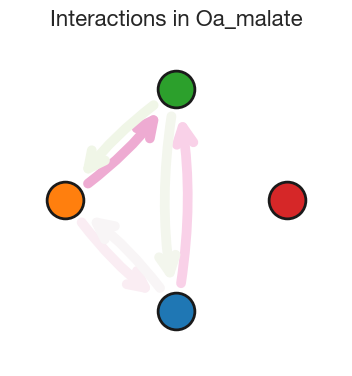

M9_malate Ct At *** -1.4872510114737096
M9_malate At Oa ** 1.095482805526471
M9_malate Ct Ml * 1.9624088622139757
M9_malate At Ml ** 2.1340040814709758


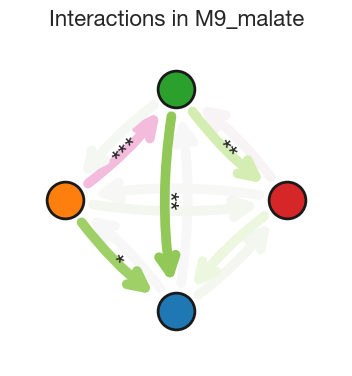

M9_malate+thiamine Ct Oa *** -1.3603295262040973
M9_malate+thiamine Ml Oa * 0.33714371718482283
M9_malate+thiamine Oa Ml * 1.672514392795712


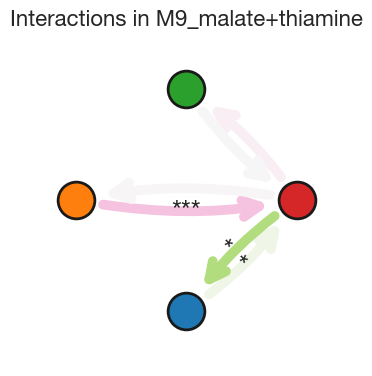

M9_malate+thiamine+biotin+cysteine+proline Ct Ml ** -1.0849870154235877
M9_malate+thiamine+biotin+cysteine+proline At Ml ** -0.892159058960253
M9_malate+thiamine+biotin+cysteine+proline Oa Ml ** -0.769969168427318


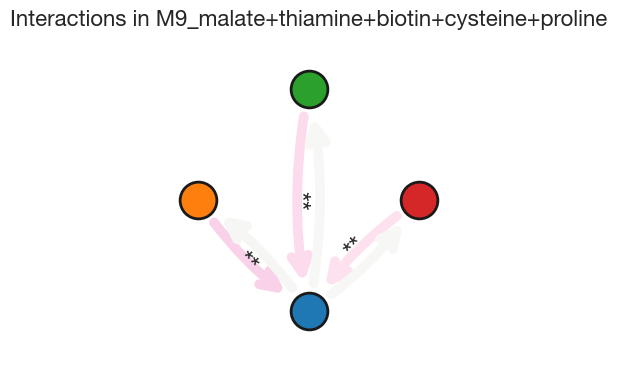

In [227]:
import matplotlib.patches as mpatches

tab10 = sns.color_palette('tab10')
cs_palette = {'No CS': 'w', 'Malate': tab10[4],'Mannose': tab10[8], 'Isoleucine': tab10[6]}

# Example for a specific medium
# df_medium = interactions_df[interactions_df['Sh'] == 'Spent'].copy()

# Position species on a circle or grid
species_list = ['At', 'Ct', 'Ml', 'Oa']
n = len(species_list)
angles = np.linspace(-np.pi*1.5, 0.5*np.pi, n, endpoint=False)
species_pos = {species: (np.cos(angle), np.sin(angle)) 
               for species, angle in zip(species_list, angles)}

# Create plot



# Normalize interaction strength for coloring
norm = plt.Normalize(vmin=-4, 
                     vmax=4)
cmap = plt.cm.PiYG  # Red for negative, blue for positive
for i, medium in enumerate(interactions_df.Medium.unique()):
    df_medium = interactions_df.loc[interactions_df.Medium == medium].copy()
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    df_medium.sort_values(by = 'log10 ratio', inplace = True)
    # Draw arrows for each interaction
    for _, row in df_medium.iterrows():
        focal = row['Focal species']
        partner = row['Partner species']
        strength = row['log10 ratio']
        
        x1, y1 = species_pos[partner]
        x2, y2 = species_pos[focal]
        
        # Draw curved fish-hook style arrow
        arrow = mpatches.FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle='->', 
            mutation_scale=30,
            linewidth=7,
            # fill = True,
            # edgecolor = 'k',
            color=cmap(norm(strength)),
            alpha=1,
            connectionstyle="arc3,rad=0.1",  # Creates curved arrow (rad controls curvature)
            shrinkA=20, shrinkB=20
        )
        ax.add_patch(arrow)

        # Calculate position for annotation (along the curved path)
        # For arc3 with rad=0.1, approximate the midpoint of the curve
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        
        # Offset perpendicular to the line to follow the curve
        dx, dy = x2 - x1, y2 - y1
        length = np.sqrt(dx**2 + dy**2)
        rad = 0.1  # Must match the rad in connectionstyle
        # Perpendicular offset for the annotation
        offset_x = -dy / length * rad #* length
        offset_y = dx / length * rad #* length
        
        # Calculate rotation angle of the arrow
        angle = np.degrees(np.arctan2(dy, dx))
        # Adjust angle to keep text readable (not upside down)
        if angle > 90:
            angle -= 180
        elif angle < -90:
            angle += 180
        
        signi = row['Significance annot']
        # Annotate with interaction score
        if signi:
            ax.text(mx - offset_x, my - offset_y, 
                    f'{signi}', 
                    ha='center', va='center',
                    rotation=angle, 
                    fontsize=20, 
                    fontweight='bold'
                    )
            print(medium, partner, focal, signi, strength)
            
        # ax.axvspan(-2,2, color = cs_palette[row['CS']], alpha = 0.1)
        # Or annotate with significance markers
        # if row['Corrected pvalue'] < 0.001:
        #     sig_marker = '***'
        # elif row['Corrected pvalue'] < 0.01:
        #     sig_marker = '**'
        # elif row['Corrected pvalue'] < 0.05:
        #     sig_marker = '*'
        # else:
        #     sig_marker = ''
        # 
        # if sig_marker:
        #     ax.text(mx + offset_x, my + offset_y, sig_marker, 
        #             ha='center', va='center', fontsize=12, fontweight='bold')



    # Draw species points
    for species, (x, y) in species_pos.items():
        ax.scatter(x, y, s=700, color=species_palette[species], 
                edgecolor='k', linewidth=2, zorder=10)
        # ax.text(x, y+0.3, species, ha='center', va='center', 
        #     fontsize=14, fontweight='bold', color='k')
        
    # if i == 0:
        # Add colorbar
        
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Interactions in {medium}', fontsize=16)

    plt.tight_layout()
    plt.savefig(figure_folder / f'interaction_network_{medium}.pdf', bbox_inches='tight')
    plt.show()

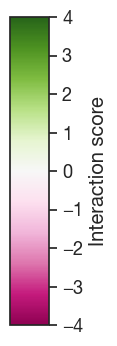

In [228]:
fig, ax = plt.subplots(1,1, figsize = (0.5,4))
# ax.axis('off')  # Hide the axis instead of removing it
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
cbar = plt.colorbar(sm, cax=ax, label='Interaction score')
plt.savefig(figure_folder / f'colorbar_only.pdf', bbox_inches='tight')
plt.show()


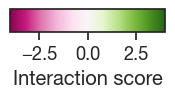

In [229]:
fig, ax = plt.subplots(1,1, figsize = (2,0.3))
# ax.axis('off')  # Hide the axis instead of removing it
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
cbar = plt.colorbar(sm, cax=ax, label='Interaction score', orientation='horizontal')
plt.savefig(figure_folder / f'colorbar_only_h.pdf', bbox_inches='tight')
plt.show()


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_81818/1253811593.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([0], [0], s=300, c=species_palette[partner], edgecolor='k', linewidth=2)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_81818/1253811593.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([1], [0], s=300, c=species_palette[focal], edgecolor='k', linewidth=2)
/var

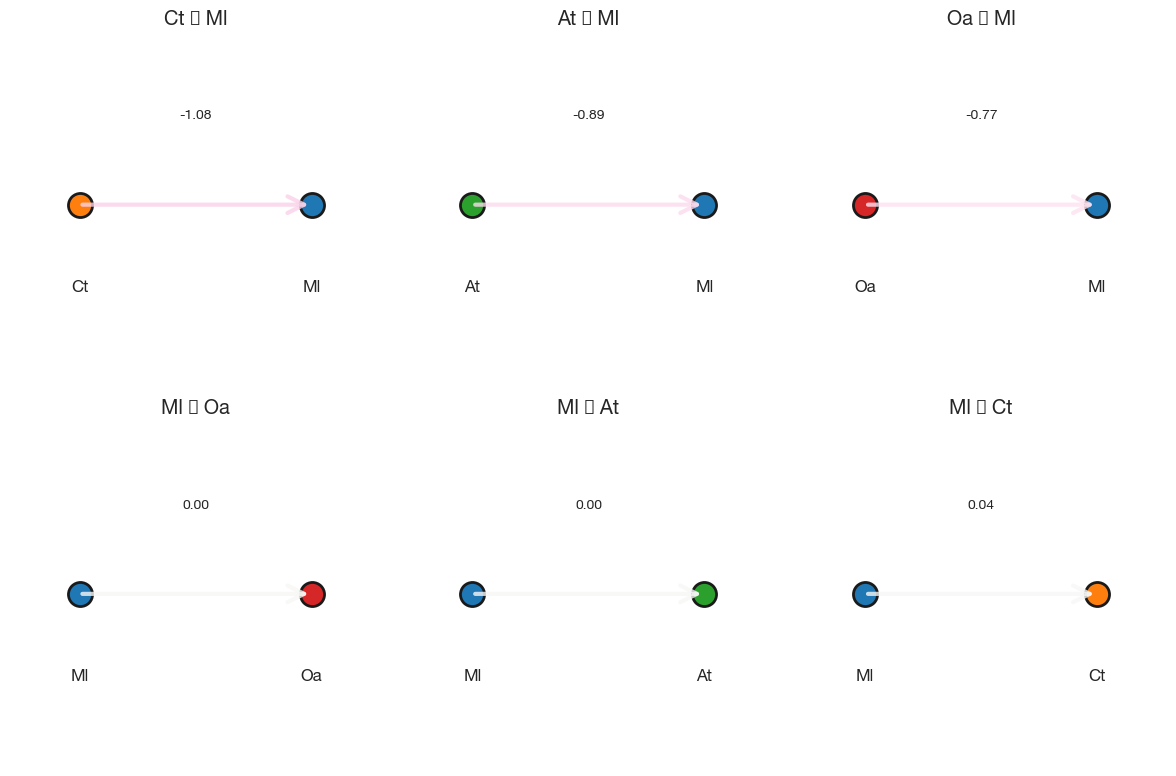

In [230]:
# Plot individual pairs
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (_, row) in enumerate(df_medium.head(6).iterrows()):
    ax = axes[idx]
    focal = row['Focal species']
    partner = row['Partner species']
    strength = row['log10 ratio']
    
    # Two points
    ax.scatter([0], [0], s=300, c=species_palette[partner], edgecolor='k', linewidth=2)
    ax.scatter([1], [0], s=300, c=species_palette[focal], edgecolor='k', linewidth=2)
    
    # Arrow
    arrow = mpatches.FancyArrowPatch(
        (0, 0), (1, 0),
        arrowstyle='->',
        mutation_scale=30,
        linewidth=3,
        color=cmap(norm(strength)),
        alpha=0.8
    )
    ax.add_patch(arrow)
    
    # Labels
    ax.text(0, -0.15, partner, ha='center', fontsize=12, fontweight='bold')
    ax.text(1, -0.15, focal, ha='center', fontsize=12, fontweight='bold')
    ax.text(0.5, 0.15, f'{strength:.2f}', ha='center', fontsize=10)
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 0.3)
    ax.axis('off')
    ax.set_title(f'{partner} → {focal}')

plt.tight_layout()
plt.show()

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_81818/2048964825.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


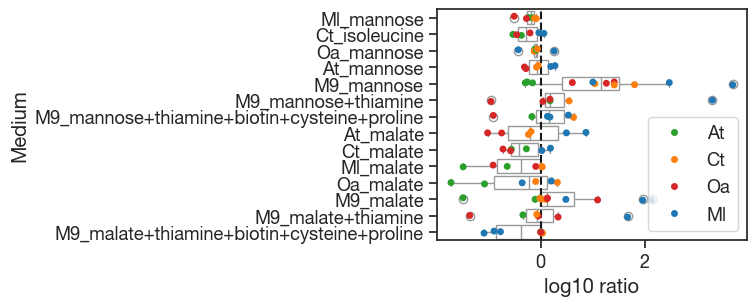

In [231]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', hue = 'Focal species', palette=species_palette, ax=ax)
sns.boxplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
# plt.savefig('Interactions mannose.pdf')

In [232]:
interactions_df.loc[interactions_df.isna().any(axis=1)]

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval,Significance annot,Fresh,abs(log10 ratio),Effect size (permutations),Effect size (lognormal dist),abs effect (permutations),abs effect (lognormal dist),Significance,abs log10 ratio,CS
66,At,Ct,Oa_malate,-1.720277,NaN,NaN,NaN,NaN,NaN,,Spent,1.720277,-1.470938,-1.640447,1.470938,1.640447,False,1.720277,Malate
68,At,Ml,Oa_malate,-1.075844,NaN,NaN,NaN,NaN,NaN,,Spent,1.075844,-0.923013,-1.026847,0.923013,1.026847,False,1.075844,Malate


# Heatmaps


Ml_mannose
Ct_isoleucine
Oa_mannose
At_mannose
M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_malate
Ct_malate
Ml_malate
Oa_malate
M9_malate
M9_malate+thiamine
M9_malate+thiamine+biotin+cysteine+proline


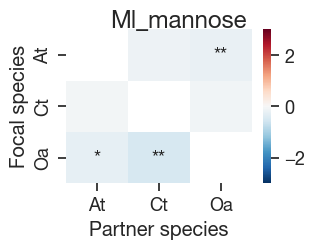

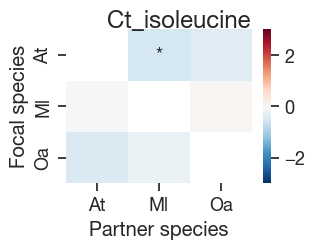

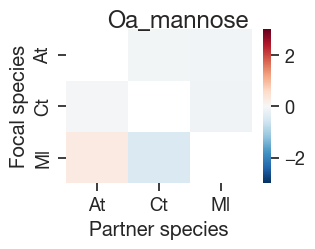

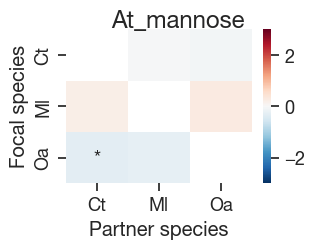

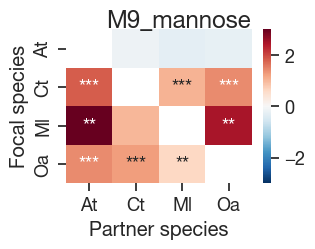

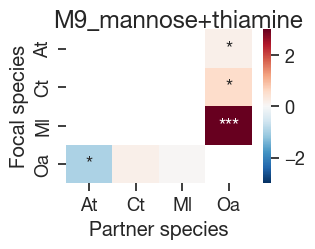

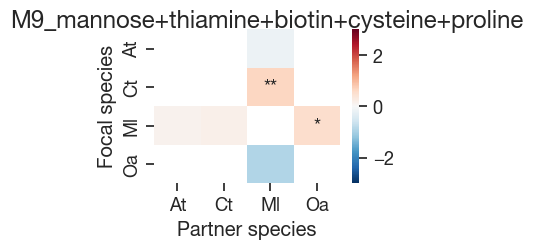

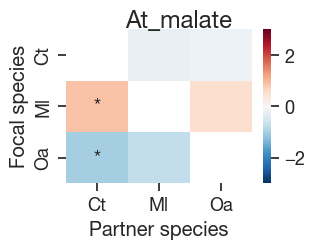

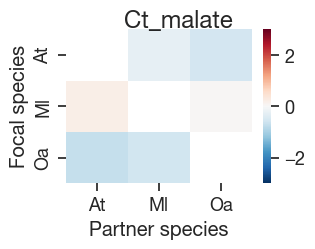

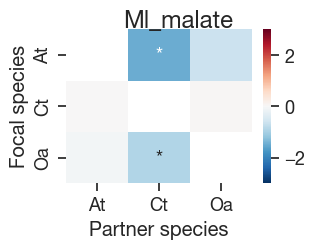

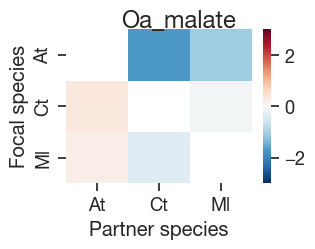

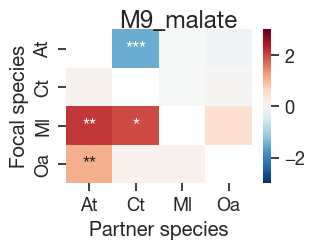

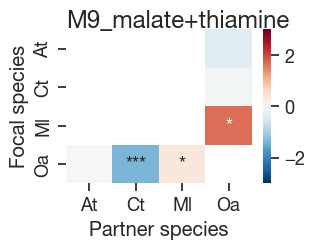

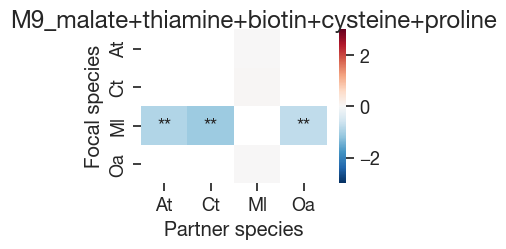

In [233]:
for medium in interactions_df.Medium.unique():
    print(medium)
    dfm = interactions_df.loc[interactions_df.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1, figsize = (3,2))
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')
    plt.savefig(figure_folder / f'interaction_heatmap_{medium}.pdf')

In [234]:
cfu_df = cfu_df_dict['spent_mannose2']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

NameError: name 'cfu_df_dict' is not defined

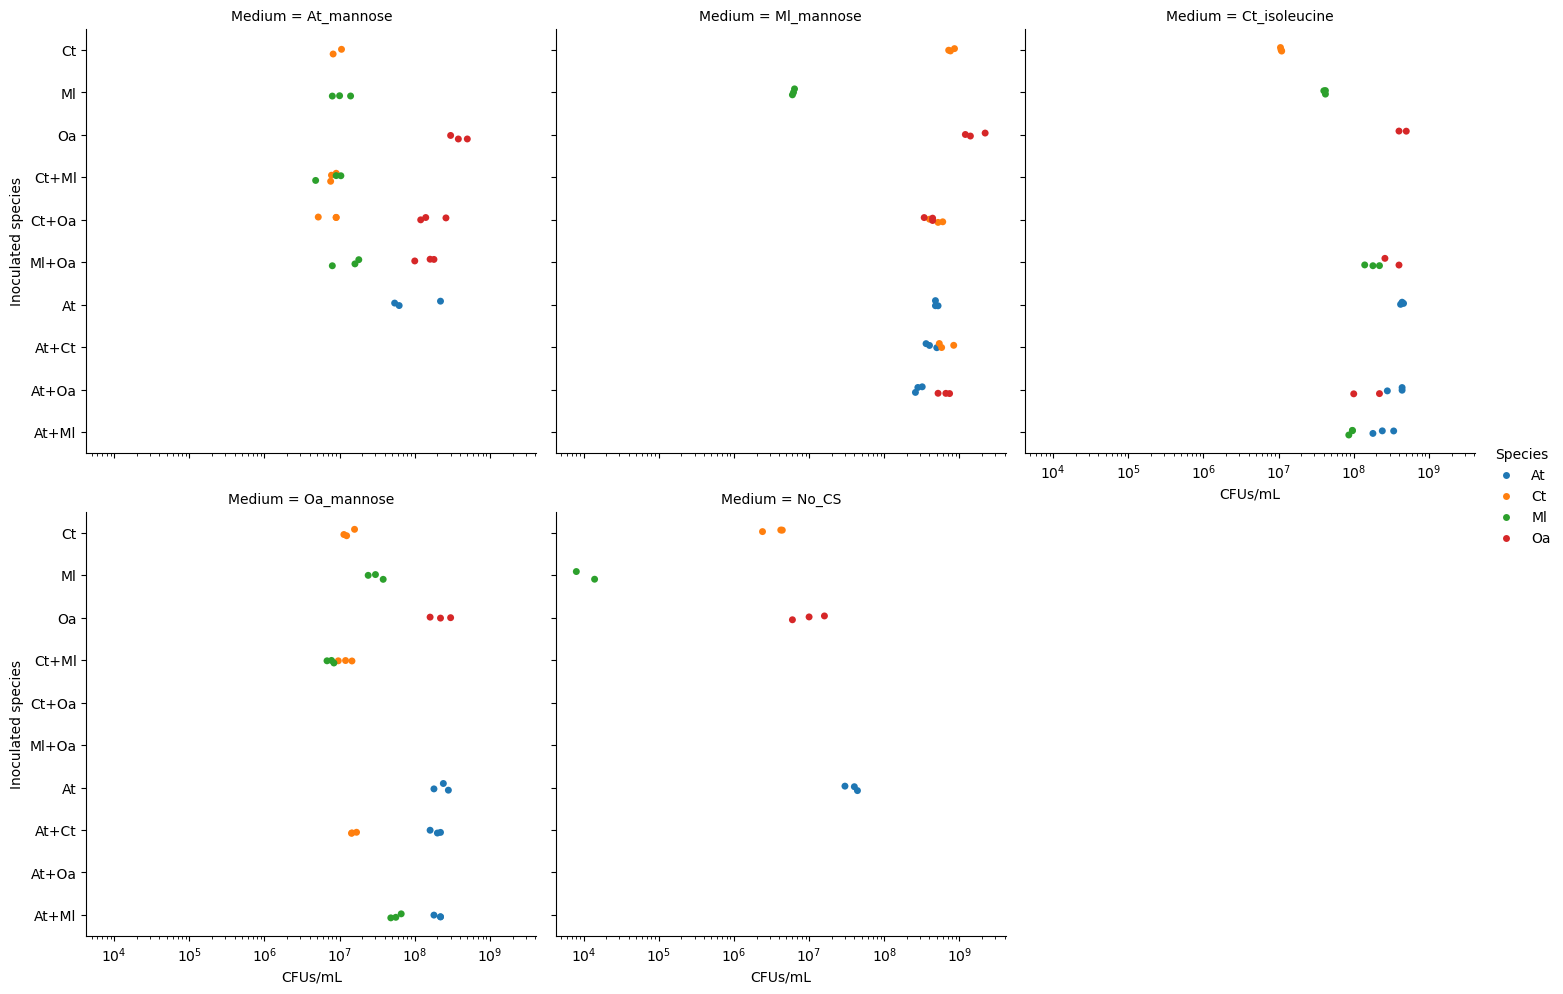

In [ ]:
cfu_df = cfu_df_dict['spent_mannose3']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

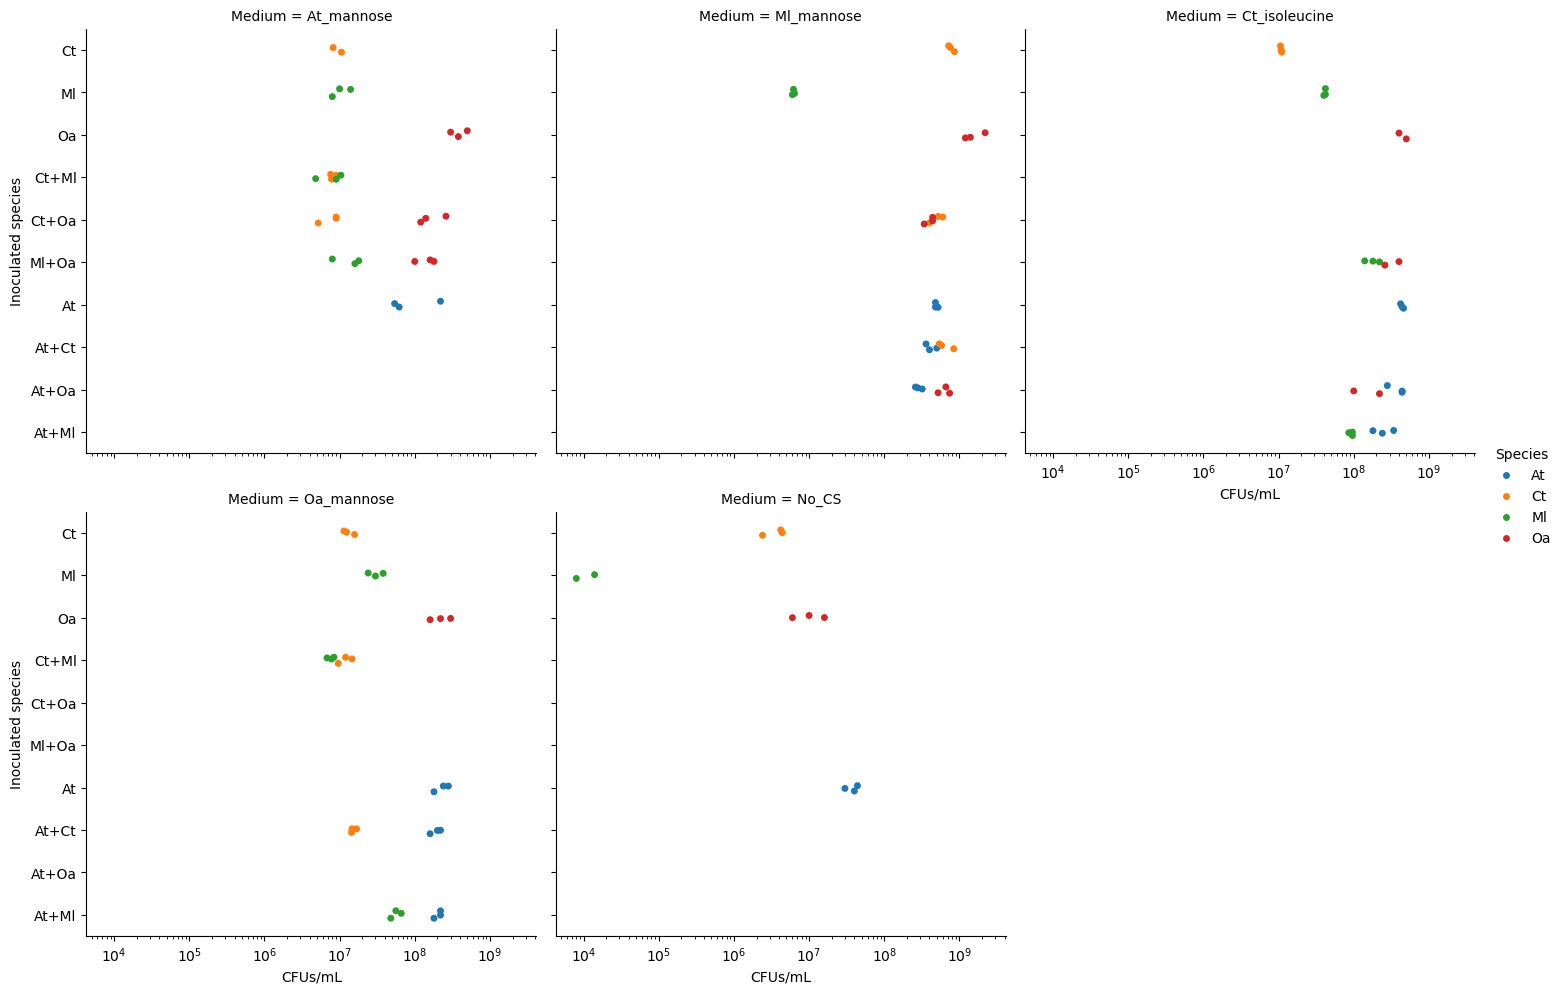

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

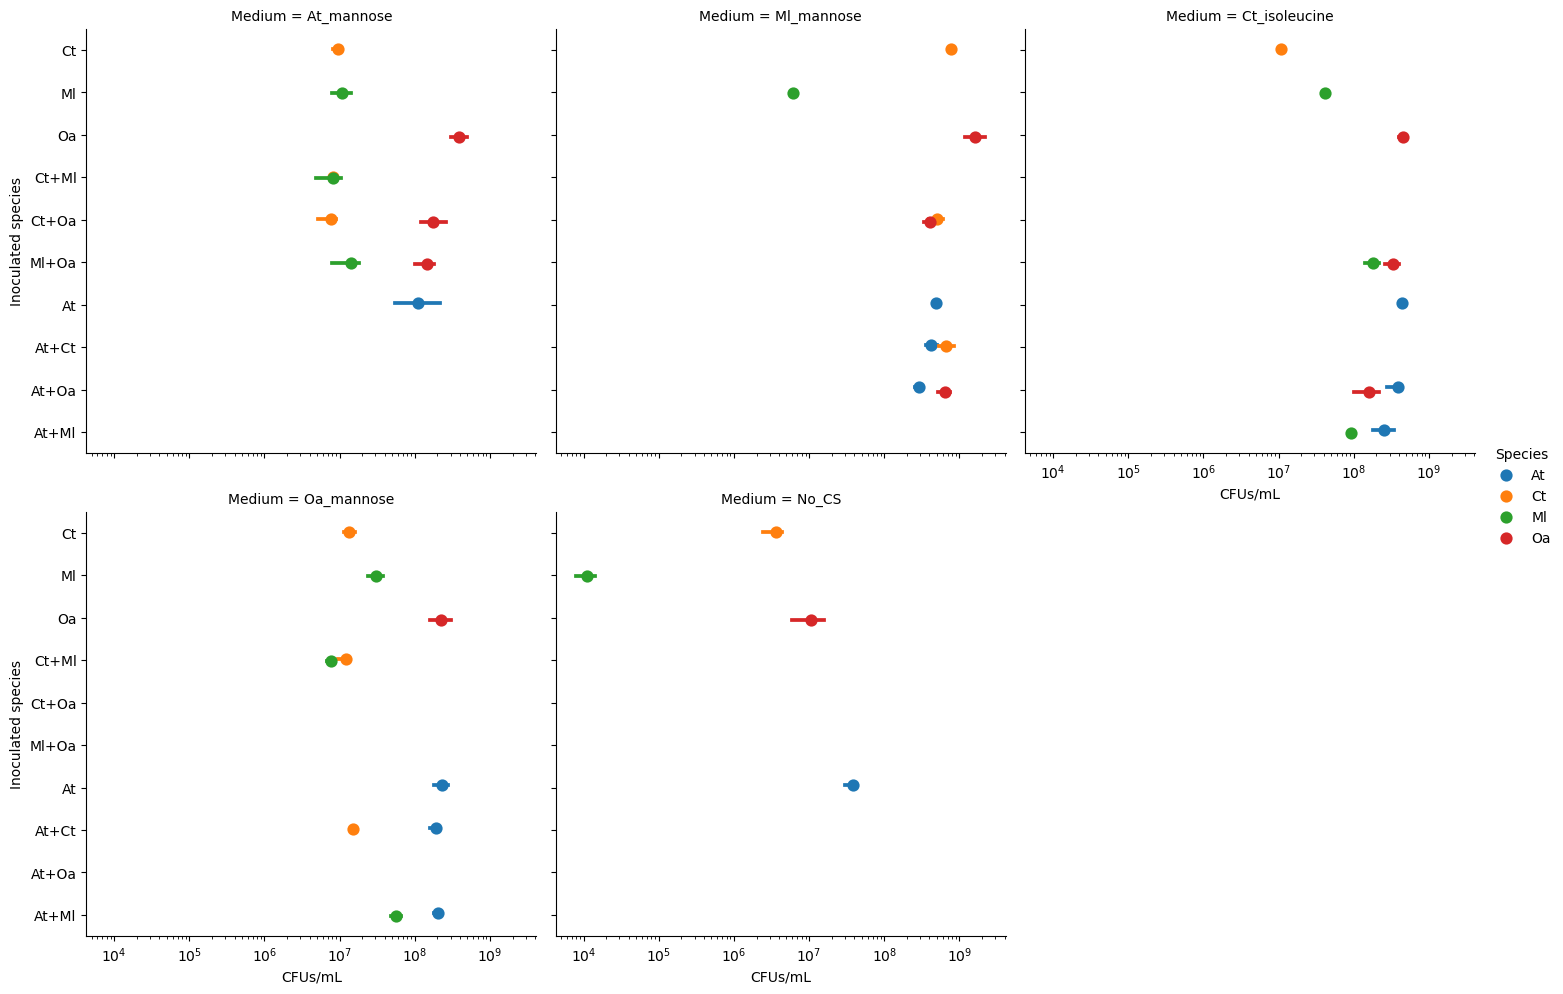

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'point', dodge=True, markers="o", linestyle = 'None')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

# Quantify interactions

In [ ]:
# Join spent mannose data
spent_mannose_cfu = pd.concat([cfu_df_dict['spent_mannose2'], cfu_df_dict['spent_mannose3']])
spent_mannose_cfu.reset_index(inplace=True, drop = True)

In [ ]:
spent_mannose_cfu.to_csv('cfus_spent_mannose.csv')

## Spent medium

In [ ]:
spent_mannose_cfu['Inoculated species'].astype('str')

0      nan
1      nan
2      nan
3      nan
4      nan
      ... 
715     Ml
716     Ml
717     Oa
718     Oa
719     Oa
Name: Inoculated species, Length: 720, dtype: object

In [ ]:
spent_mannose_cfu['Is coculture'] = spent_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in spent_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = spent_mannose_cfu.loc[spent_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
spent_mannose_isoleucine_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_isoleucine_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('isoleucine')]
spent_mannose_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('mannose')]

# Fresh mannose

In [ ]:
fresh_mannose_cfu = cfu_df_dict['fresh_mannose']
fresh_mannose_cfu['Is coculture'] = fresh_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in fresh_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = fresh_mannose_cfu.loc[fresh_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        # lrr_s1 = np.log10(s1_growth_in_co.mean()/s1_growth_in_mono.mean())
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        
        # the uncertainty package estimates matches with how to in https://en.wikipedia.org/wiki/Propagation_of_uncertainty
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
fresh_mannose_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,Ct,Ml,At_mannose,-0.042771,0.094802,0.318843
1,Ml,Ct,At_mannose,0.360580,0.428275,0.181713
2,Ct,Oa,At_mannose,-0.067773,0.116755,0.201653
3,Oa,Ct,At_mannose,-0.274574,0.240609,0.006504
4,Ml,Oa,At_mannose,0.363594,0.329930,0.085762
5,Oa,Ml,At_mannose,-0.231527,0.253162,0.022293
6,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230
7,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410
8,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121
9,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636


In [ ]:
fresh_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01
1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05
2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02
3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06
4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02
5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07
6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04
7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05
8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06
9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06


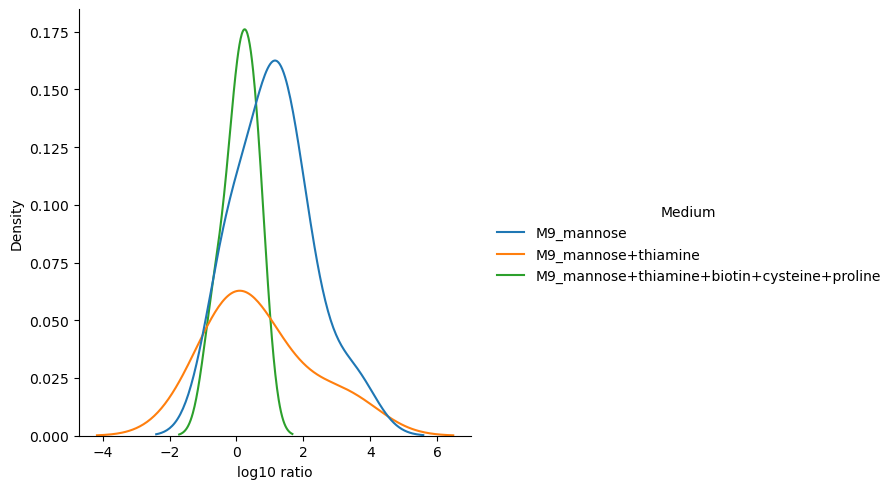

In [ ]:
ax = sns.displot(data = fresh_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

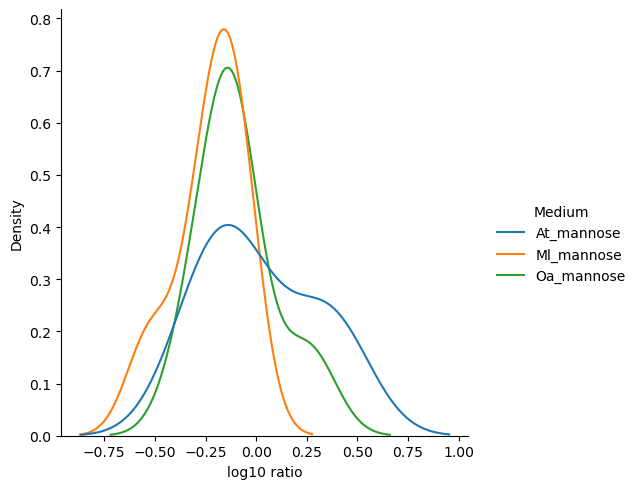

In [ ]:
ax = sns.displot(data = spent_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [ ]:
all_interactions = pd.concat([fresh_mannose_interactions, spent_mannose_interactions]).reset_index()

In [ ]:
all_interactions['log10 pval'] = np.log10(all_interactions['T-test pvalue'])

<Axes: xlabel='log10 ratio', ylabel='Medium'>

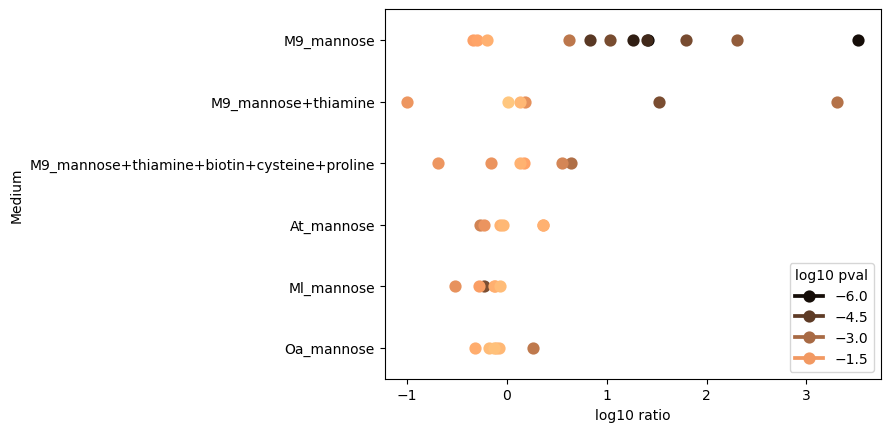

In [ ]:
sns.pointplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_77193/3074553416.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


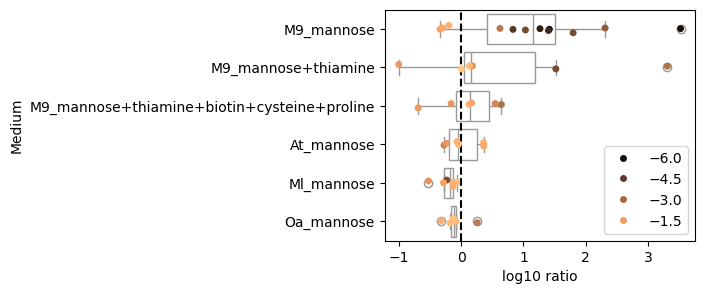

In [ ]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper', ax=ax)
sns.boxplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
plt.savefig('Interactions mannose.pdf')

## Heatmaps

In [ ]:
all_interactions['Significance annot'] = ''
for i, row in all_interactions.iterrows():
    if 0.01 < row['T-test pvalue'] < 0.05:
        annot = '*'
    elif 0.001 < row['T-test pvalue'] < 0.01:
        annot = '**'
    elif row['T-test pvalue'] < 0.001:
        annot = '***'
    else:
        annot = ''
    all_interactions.at[i, 'Significance annot'] = annot
    

In [ ]:
all_interactions

,index,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,log10 pval,Significance annot
0,0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01,-0.787999,
1,1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05,-4.007693,***
2,2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02,-1.271082,
3,3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06,-5.981531,***
4,4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02,-1.152318,
5,5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07,-6.426428,***
6,6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04,-3.978658,***
7,7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05,-4.601019,***
8,8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06,-5.089934,***
9,9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06,-5.444935,***


M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_mannose
Ml_mannose
Oa_mannose


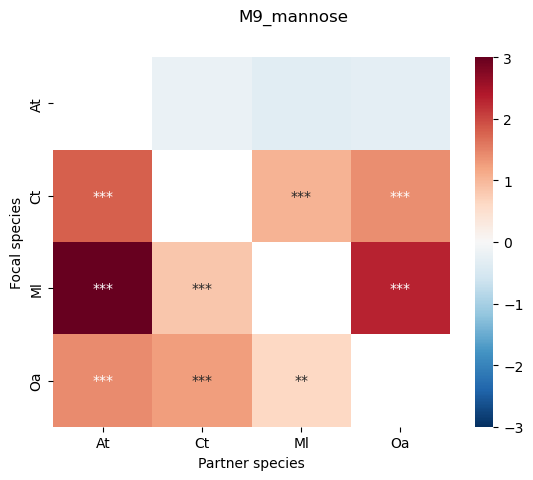

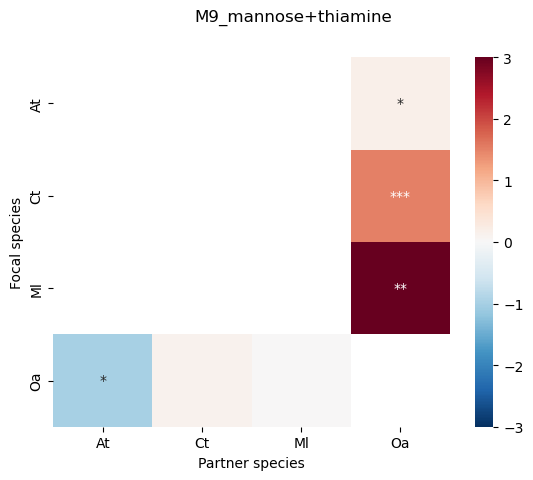

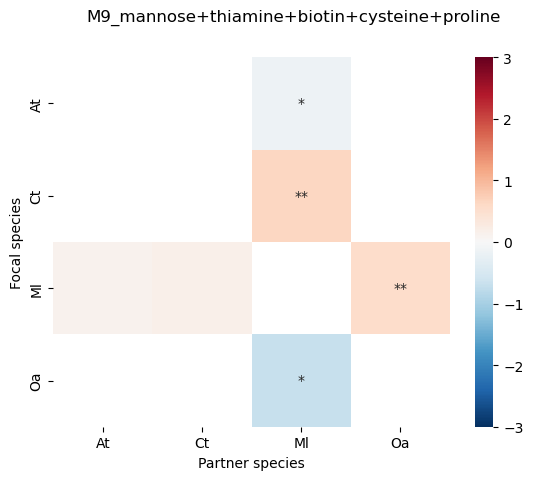

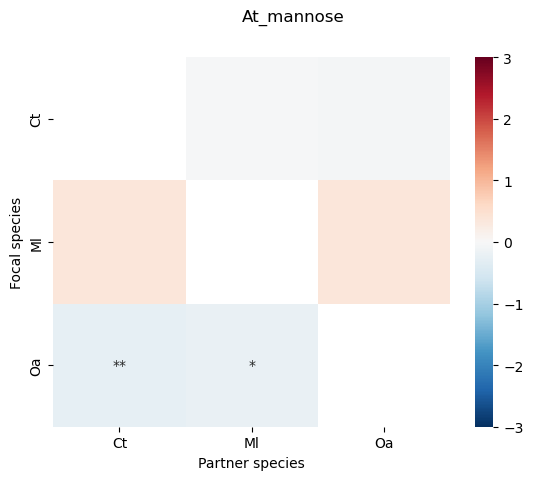

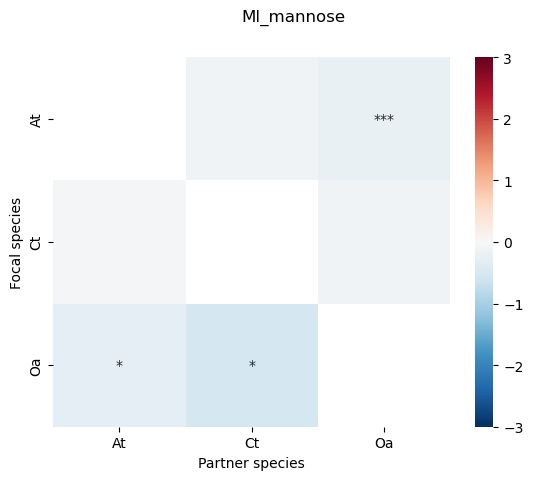

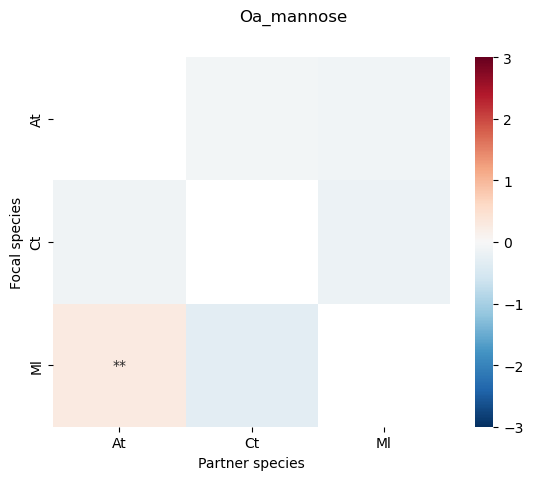

In [ ]:
for medium in all_interactions.Medium.unique():
    print(medium)
    dfm = all_interactions.loc[all_interactions.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1)
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')